In [1]:
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import numpy as np
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scipy.stats as stats
import random
import copy
from tqdm.notebook import tqdm

In [2]:
# ==============================================================================
# 1. GRID INITIALIZATION & ENHANCEMENTS (Based on Enhanced IEEE 33-Bus Paper)
# ==============================================================================
# Load the standard system 
net = pn.case33bw()

# A. Add Distributed Generation (DG) Units (0.2 MW each) 
# Paper locations: Buses 18, 22, 25, 33 -> Python indices 17, 21, 24, 32
dg_buses = [17, 21, 24, 32]
for bus in dg_buses:
    pp.create_sgen(net, bus=bus, p_mw=0.2, q_mvar=0, name=f"DG_Bus_{bus+1}")

# B. Add Reactive Power Compensators (RPCs) 
# Paper locations: Bus 18 (0.4 MVAR) and Bus 33 (0.6 MVAR)
pp.create_shunt(net, bus=17, q_mvar=-0.4, name="RPC_Bus_18")
pp.create_shunt(net, bus=32, q_mvar=-0.6, name="RPC_Bus_33")

# C. Add Switchable Tie-Lines (Normally Open) 
# Branch 33: 21-8; Branch 34: 12-22; Branch 35: 25-29
pp.create_line_from_parameters(net, from_bus=20, to_bus=7, length_km=1, r_ohm_per_km=2.0, 
                               x_ohm_per_km=2.0, c_nf_per_km=0, max_i_ka=1, name="TieLine_33", in_service=False)
pp.create_line_from_parameters(net, from_bus=11, to_bus=21, length_km=1, r_ohm_per_km=2.0, 
                               x_ohm_per_km=2.0, c_nf_per_km=0, max_i_ka=1, name="TieLine_34", in_service=False)
pp.create_line_from_parameters(net, from_bus=24, to_bus=28, length_km=1, r_ohm_per_km=0.5, 
                               x_ohm_per_km=0.5, c_nf_per_km=0, max_i_ka=1, name="TieLine_35", in_service=False)

np.int64(39)

In [3]:
# ==============================================================================
# 2. GEOSPATIAL MAPPING (LINBIAN, TAIWAN)
# ==============================================================================
net.bus_geodata = pd.DataFrame(columns=['x', 'y'], index=net.bus.index)
G = nx.Graph()
G.add_edges_from(net.line[['from_bus', 'to_bus']].values)
pos = nx.kamada_kawai_layout(G)

for bus_id, coords in pos.items():
    net.bus_geodata.loc[bus_id, 'x'] = coords[0]
    net.bus_geodata.loc[bus_id, 'y'] = coords[1]

# Scale to Linbian Township coordinates
base_lat, base_lng = 22.434, 120.516
x_min, x_max = net.bus_geodata.x.min(), net.bus_geodata.x.max()
y_min, y_max = net.bus_geodata.y.min(), net.bus_geodata.y.max()
x_range, y_range = (x_max - x_min) or 1, (y_max - y_min) or 1

net.bus_geodata.x = base_lng + ((net.bus_geodata.x - x_min) / x_range - 0.5) * 0.045
net.bus_geodata.y = base_lat + ((net.bus_geodata.y - y_min) / y_range - 0.5) * 0.045

# Create GeoDataFrame for spatial analysis
gdf_microgrid = gpd.GeoDataFrame(net.bus_geodata, 
                                 geometry=[Point(xy) for xy in zip(net.bus_geodata.x, net.bus_geodata.y)], 
                                 crs="EPSG:4326")

In [4]:
# ==============================================================================
# 3. TYPHOON WIND FIELD CALCULATION (MERANTI - ID: 201614)
# ==============================================================================
def calculate_distance(lat1, lon1, lat2, lon2):
    """Calculates distance in km between two GPS points."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi, dlambda = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def get_local_wind(dist_km, v_max, r_max=40.0):
    """Rankine Vortex model: Estimates wind speed at a specific distance from the eye."""
    if dist_km <= r_max:
        return v_max * (dist_km/r_max)
    else:
        return v_max * ((r_max/dist_km)**0.5)

# Load JMA Typhoon Data
df_typhoon = pd.read_csv('raw/typhoon_data.csv')

# Target Typhoon Meranti (201614)
target_sid = 201614
storm_df = df_typhoon[df_typhoon['seq_id'] == target_sid].copy()

# Find the peak wind impact for the microgrid during this storm
storm_df['dist'] = storm_df.apply(lambda r: calculate_distance(r.lat, r.lng, base_lat, base_lng), axis=1)
storm_df['local_wind_knots'] = storm_df.apply(lambda r: get_local_wind(r.dist, r.wind), axis=1)
peak_hour = storm_df.sort_values(by='local_wind_knots', ascending=False).iloc[0]

# Convert knots to m/s
vmax_ms = peak_hour['wind'] * 0.514444

# Map current wind speeds to the microgrid buses
net.bus_geodata['wind_speed_ms'] = [get_local_wind(calculate_distance(peak_hour.lat, peak_hour.lng, row.y, row.x), vmax_ms) 
                                    for idx, row in net.bus_geodata.iterrows()]

print(f"Targeting Typhoon ID: {target_sid}")
print(f"Peak Local Wind Speed at Grid: {peak_hour.local_wind_knots:.2f} knots (~{vmax_ms:.2f} m/s)")

Targeting Typhoon ID: 201614
Peak Local Wind Speed at Grid: 95.13 knots (~54.02 m/s)


In [5]:
# ==============================================================================
# 4. RISK MODELING (FRAGILITY & MONTE CARLO SIMULATION)
# ==============================================================================
# Fragility Parameters (Lognormal Distribution)
MEDIAN_FAIL = 55.0  # Wind speed at which 50% of lines fail
BETA = 0.15         # Uncertainty parameter

# Assign Probabilities of Failure (Pf) to each line
net.line['prob_failure'] = 0.0
for idx, line in net.line.iterrows():
    w_from = net.bus_geodata.loc[line.from_bus, 'wind_speed_ms']
    w_to = net.bus_geodata.loc[line.to_bus, 'wind_speed_ms']
    max_w = max(w_from, w_to)
    net.line.loc[idx, 'prob_failure'] = stats.lognorm.cdf(max_w, s=BETA, scale=MEDIAN_FAIL)

# Monte Carlo Simulation
NUM_SCENARIOS = 1000
total_load_demand = net.load.p_mw.sum()
results_served = []

print(f"[INFO] Running {NUM_SCENARIOS} Monte Carlo Iterations")
for _ in tqdm(range(NUM_SCENARIOS), desc="Risk Assessment"):
    scen_net = copy.deepcopy(net)
    
    # Simulate failures
    for idx, line in scen_net.line.iterrows():
        if random.random() < line['prob_failure']:
            scen_net.line.loc[idx, 'in_service'] = False
            
    # Solve Power Flow
    try:
        pp.runpp(scen_net)
        results_served.append(scen_net.res_load.p_mw.sum())
    except:
        results_served.append(0.0) # Assume blackout on convergence failure

# Calculate Expected Energy Not Supplied (EENS)
expected_loss = total_load_demand - np.mean(results_served)
lolp = sum(1 for x in results_served if x < total_load_demand) / NUM_SCENARIOS

print(f"\n--- RISK REPORT (Typhoon {target_sid}) ---")
print(f"Total Grid Demand: {total_load_demand:.3f} MW")
print(f"Expected Load Loss: {expected_loss:.3f} MW")
print(f"Loss of Load Probability: {lolp * 100:.1f}%")

[INFO] Running 1000 Monte Carlo Iterations


Risk Assessment:   0%|          | 0/1000 [00:00<?, ?it/s]


--- RISK REPORT (Typhoon 201614) ---
Total Grid Demand: 3.715 MW
Expected Load Loss: 2.623 MW
Loss of Load Probability: 99.9%


In [7]:
results_served

[np.float64(0.0),
 np.float64(1.33),
 np.float64(1.6099999999999999),
 np.float64(1.6),
 np.float64(0.0),
 np.float64(2.525),
 np.float64(1.5499999999999998),
 np.float64(0.0),
 np.float64(1.2999999999999998),
 np.float64(1.66),
 np.float64(0.37),
 np.float64(1.6600000000000001),
 np.float64(1.4),
 np.float64(0.0),
 np.float64(1.01),
 np.float64(0.28),
 np.float64(0.0),
 np.float64(2.39),
 np.float64(0.28),
 np.float64(1.24),
 np.float64(2.665),
 np.float64(1.685),
 np.float64(0.64),
 np.float64(0.64),
 np.float64(1.35),
 np.float64(0.73),
 np.float64(1.8650000000000002),
 np.float64(1.42),
 np.float64(1.48),
 np.float64(0.45999999999999996),
 np.float64(1.865),
 np.float64(2.285),
 np.float64(0.0),
 np.float64(1.2999999999999998),
 np.float64(1.01),
 np.float64(3.04),
 np.float64(1.48),
 np.float64(1.4100000000000001),
 np.float64(1.74),
 np.float64(0.0),
 np.float64(0.49),
 np.float64(1.6600000000000001),
 np.float64(1.42),
 np.float64(0.0),
 np.float64(0.19),
 np.float64(0.0),
 np.f

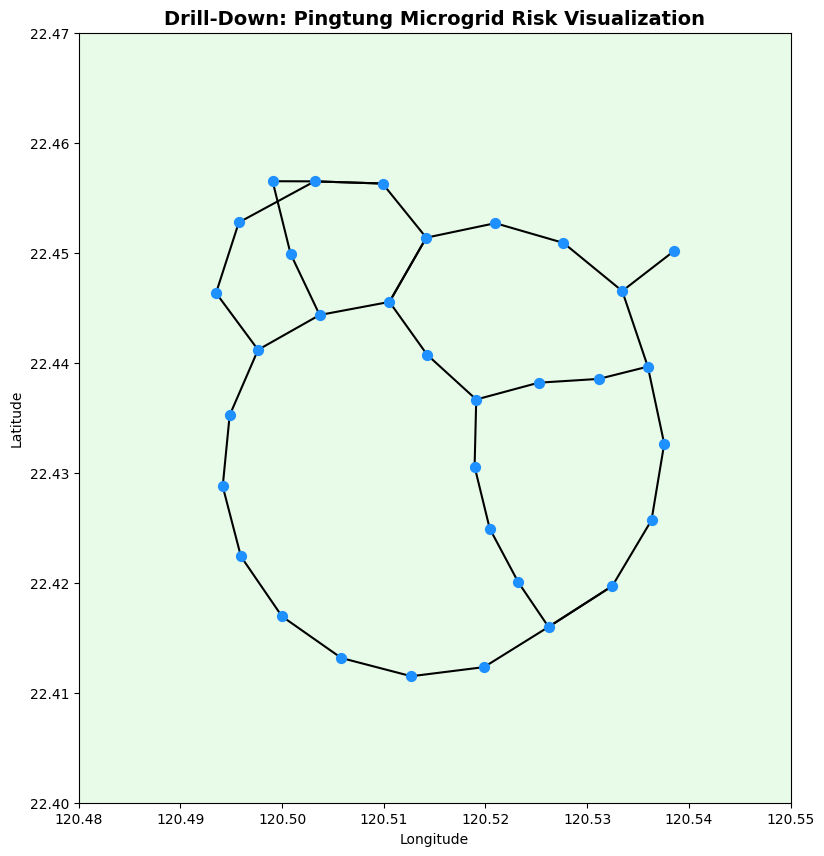

In [6]:
# ==============================================================================
# 5. GEOGRAPHICAL DRILL-DOWN VISUALIZATION
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 10))

# Fetch base map on the fly
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
world.columns = world.columns.str.lower()
world[world['name'] == "Taiwan"].plot(ax=ax, color='lightgreen', edgecolor='black', alpha=0.2)

# Plot Microgrid Topology
for idx, line in net.line.iterrows():
    f, t = net.bus_geodata.loc[line.from_bus], net.bus_geodata.loc[line.to_bus]
    ax.plot([f.x, t.x], [f.y, t.y], color='black', lw=1.5, zorder=3)

gdf_microgrid.plot(ax=ax, color='dodgerblue', markersize=50, zorder=4)

# Formatting
ax.set_xlim(120.48, 120.55); ax.set_ylim(22.40, 22.47)
ax.set_title("Drill-Down: Pingtung Microgrid Risk Visualization", fontsize=14, fontweight='bold')
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()